# ASSIGNMENT 1:FINANCIAL ECONOMETRICS  PROJECT1
## PROJECT HANDBOOK
## MODELING CHALLENGES IN TIMME SERIES

#### Name:  Derrec MMadzvamutse
#### Hasts 201
#### Reg Nuumber :  R2419467

## PROBLEM ADDRESSED
* Lack of Interpretation
* Multicolinearity
* Skewness
* Outliers
  

## Uploading Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

df = yf.download("AAPL", start="2018-01-01", end="2025-12-31", auto_adjust=True)

# Flatten multi-level columns if yfinance returns them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.index.name = "Date"

# Create return variables
df["Returns"] = df["Close"].pct_change()
df["Log_Returns"] = np.log(df["Close"] / df["Close"].shift(1))

# Remove missing values
df.dropna(inplace=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Price: ${float(df['Close'].iloc[0]):.2f} → ${float(df['Close'].iloc[-1]):.2f}")

df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (2009, 7)
Date range: 2018-01-03 to 2025-12-30
Price: $40.30 → $272.82


Price,Close,High,Low,Open,Volume,Returns,Log_Returns
Date,,,,,,,
2018-01-03,40.297165,40.839984,40.233995,40.367358,118071600,-0.000174,-0.000174
2018-01-04,40.484344,40.587293,40.262071,40.369696,89738400,0.004645,0.004634
2018-01-05,40.945255,41.031824,40.489009,40.580258,94640000,0.011385,0.011321
2018-01-08,40.793186,41.087991,40.694914,40.793186,82271200,-0.003714,-0.003721
2018-01-09,40.788494,40.959293,40.573239,40.839968,86336000,-0.000115,-0.000115


## 1 Lack of Interpretation
1. Definition 

Lack of interpretation occurs when a statistical or machine learning model produces results that are difficult to explain economically or financially, even if the predictive performance is high.

In regression models:
$$ Y_i = \beta_0 + \beta_1 X_{1i} + \beta_2 X_{2i} + \cdots + \epsilon_i$$

the coefficients $  \beta_i $
	​

 should have meaningful financial interpretations.
When the model becomes too complex or variables are poorly explained, interpretation becomes difficult.

2. Description

Lack of interpretation means a model gives outputs or predictions that are hard to understand in practical financial terms. In financial econometrics, this makes it difficult for traders, investors, or risk managers to trust or apply the model’s results.


## Demonstration (Using AAPL Dataset)


In [ ]:
import statsmodels.api as sm

# Independent variables
X = df[["Volume", "High", "Low"]]

# Dependent variable
y = df["Returns"]

# Add constant
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()

# Display regression results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Returns   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.609
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.185
Time:                        11:15:55   Log-Likelihood:                 5072.6
No. Observations:                2009   AIC:                        -1.014e+04
Df Residuals:                    2005   BIC:                        -1.011e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0045      0.002      2.301      0.0

## Diagram (Visual Example)
#### Scatter Plot of Returns vs Volum

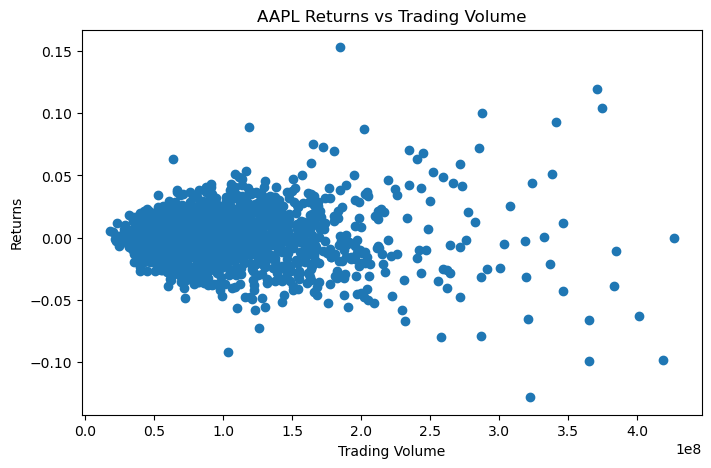

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Volume"], df["Returns"])
plt.xlabel("Trading Volume")
plt.ylabel("Returns")
plt.title("AAPL Returns vs Trading Volume")
plt.show()

## 5. Diagnosis (How to Recognize the Problem)

A lack of interpretation can be recognized when:

* Variables have unclear financial meaning
* Regression coefficients are difficult to explain
* The model contains many variables with weak relationships
* Results are statistically significant but economically meaningless

In this example:

Volume, High, and Low prices may predict returns statistically
However, explaining how each variable economically affects returns becomes difficult because:
High and Low prices are strongly related
Large trading volume does not always explain stock performance clearly

##   Damage Caused by Lack of Interpretation

Lack of interpretation can cause several problems in financial modeling:

Traders may not trust the model
Risk managers cannot clearly explain decisions
Investors may make poor financial decisions
Complex models become difficult to validate
Misinterpretation can lead to incorrect hedging or pricing strategies

Even if a model has a high $R^2$
, it may still provide little practical insight if the relationships are not understandable.

## Directions (How to Address the Problem)
##### * Use Simpler Models

   Simpler models with fewer variables are easier to interpret

   #### Example

In [5]:
X_simple = sm.add_constant(df[["Volume"]])

simple_model = sm.OLS(y, X_simple).fit()

print(simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Returns   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.542
Date:                Thu, 07 May 2026   Prob (F-statistic):              0.111
Time:                        11:23:24   Log-Likelihood:                 5071.5
No. Observations:                2009   AIC:                        -1.014e+04
Df Residuals:                    2007   BIC:                        -1.013e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0023      0.001      2.698      0.0

##  Use Correlation Analysis

* Before modeling, examine relationships between variables.
##  Visualize Relationships

  Graphs improve interpretability by helping analysts understand variable        behavior.
* Visualization helps identify volatility patterns and improves understanding of model behavior.

## 2. MULTICOLLINEARITY

### Definition

Multicollinearity refers to a phenomenon in multiple regression analysis where two or more predictor variables are highly linearly related.

Mathematically, for a regression model 
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \varepsilon
$$

Multicollinearity exists when:

$$
X_i \approx c_0 + c_1 X_j \quad \text{for } i \ne j
$$

or more generally:

$$
X_i \approx c_0 + c_1 X_j + c_2 X_k + \cdots
$$
It can also be measured using the Variance Inflation Factor (VIF):

$$
VIF_i = \frac{1}{1 - R_i^2}
$$

### Description
Multicollinearity occurs when independent variables in a regression model are highly correlated and move together.
This makes it difficult to determine the individual effect of each predictor on the dependent variable.

## Demonstration

In [6]:
X = df[['Open','High','Low','Volume']]

# Correlation matrix
corr_matrix = X.corr()
corr_matrix

Price,Open,High,Low,Volume
Price,,,,
Open,1.000000,0.999733,0.999756,-0.580627
High,0.999733,1.000000,0.999654,-0.575493
Low,0.999756,0.999654,1.000000,-0.585671
Volume,-0.580627,-0.575493,-0.585671,1.000000


## VISUALISATION

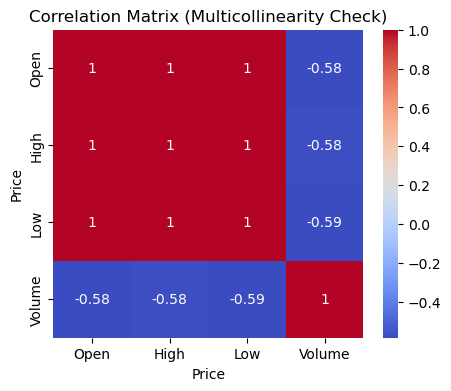

In [8]:
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (Multicollinearity Check)")
plt.show()


## Variance Inflation Factor (VIF)_ DIAGNOSIS
Multicollinearity increases the variance of coefficient estimates, making them unstable and sensitive to small changes in the data. This reduces the reliability of the model, leading to poor interpretation and potentially incorrect financial decisions such as mispricing derivatives or ineffective hedging strategies.

In [9]:
# VIF calculation
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.dropna()
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data

,Feature,VIF
0,Open,15217.498269
1,High,11542.345996
2,Low,12609.574134
3,Volume,1.941005


### Interpretation of VIF

- VIF > 10 → severe multicollinearity
- VIF between 5–10 → moderate
- VIF < 5 → acceptable

From the results, variables such as Open, High, and Low show very high VIF values, confirming strong multicollinearity.

### Damage
* Multicollinearity increases the variance of coefficient estimates, making them unstable and sensitive to small changes in the data. This reduces the reliability of the model, leading to poor interpretation and potentially incorrect financial decisions such as mispricing derivatives or ineffective hedging strategies.
* Inflated standard errors
  
## Directions (Solutions)
* Drop one of correlated variables
* Use PCA
* Use Ridge Regression

  



# 3. SKEWNESS
Skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean.




  $$
  \text{Skewness} = \frac{E[(X - \mu)^3]}{\sigma^3}  
 $$


where:
- $\mu$ = mean  
- $\sigma$ = standard deviation  

If:
- Skewness > 0 → right-skewed  
- Skewness < 0 → left-skewed

## Description
Skewness indicates whether a data distribution is more concentrated on one side of the mean, showing asymmetry.
A positive skew has a long right tail, while a negative skew has a long left tail, which can affect statistical analysis and interpretation

## Demonstration (Skewness calculation)


In [12]:
# Create returns
df['Returns'] = df['Close'].pct_change()

# Remove missing values
df = df.dropna()

# Compute skewness
skew_value = df['Returns'].skew()

print("Skewness:", skew_value)

Skewness: 0.15463171982851567


## interpretation
* Skewness > 0 → right skew
* Skewness < 0 → left skew
* The skewness value of 0.1548 is positive but close to zero, indicating that the distribution of returns is approximately symmetric with a slight right skew. This suggests that most returns are evenly distributed around the mean, with a small tendency for occasional higher positive returns.

## Diagram(Histogram)

<function matplotlib.pyplot.show(close=None, block=None)>

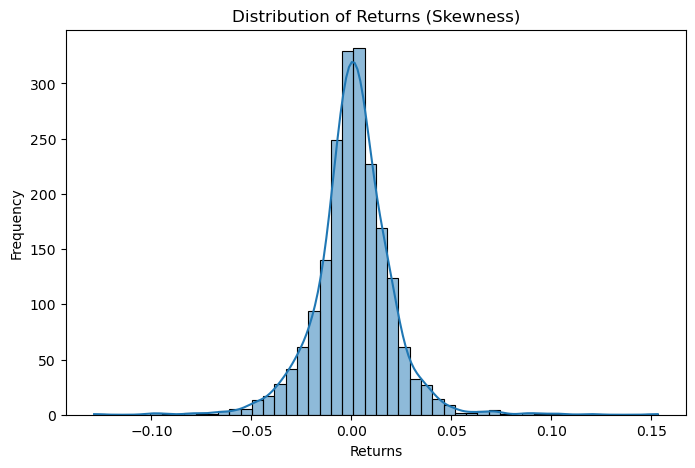

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Returns'].dropna(), bins=50, kde=True)
plt.title("Distribution of Returns (Skewness)")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.show

### Damage
* Skewness can bias estimates and lead to incorrect inferences, especially in models that assume normality like OLS regression.
* It distorts the mean toward the tail, making results less reliable and potentially leading to poor decisions and inaccurate predictions.

### DIRECTION
* Log transformation
* Use robust models
* Winsorization

## 4 OUTLIERS (UPGRADED)


## Definition
Outliers are observations that lie far from the rest of the dataset and can significantly distort statistical measures.

The Z-score for detecting outliers is given by $z_i = \frac{x_i - \mu}{\sigma}$.

An observation is considered an outlier when $|z_i| > 3$.

---

##### Interquartile Range (IQR) method
\[
IQR = Q_3 - Q_1
\]

An observation is an outlier if:
$x_i < Q_1 - 1.5\,IQR$ or $x_i > Q_3 + 1.5\,IQR$.

---

##### Description
Outliers are extreme values that significantly deviate from the majority of observations. They can distort statistical summaries and lead to misleading conclusions in financial data analysis.

## Demonstration

In [ ]:
# Step 1
df['Returns'] = df['Close'].pct_change()

# Step 2
df_clean = df.dropna().copy()

# Step 3
from scipy.stats import zscore
df_clean['z_score'] = zscore(df_clean['Returns'])

# Step 4
outliers = df_clean[np.abs(df_clean['z_score']) > 3]

# Fix: bring Date back as column
outliers = outliers.reset_index()

# Display
outliers[['Date','Returns','z_score']].head()

Price,Date,Returns,z_score
0,2018-11-02,-0.066331,-3.476816
1,2018-12-26,0.070422,3.570226
2,2019-01-03,-0.099607,-5.191586
3,2019-01-30,0.068335,3.462667
4,2019-05-13,-0.058119,-3.053657


## visualization

In [ ]:
from scipy.stats import zscore

# Work on a copy
df_clean = df.copy()

# Compute Z-score
df_clean['z_score'] = zscore(df_clean['Returns'])

# Detect outliers
outliers = df_clean[np.abs(df_clean['z_score']) > 3]

# Bring Date back as column
outliers = outliers.reset_index()

# Show results
outliers[['Date','Returns','z_score']].head()

Price,Date,Returns,z_score


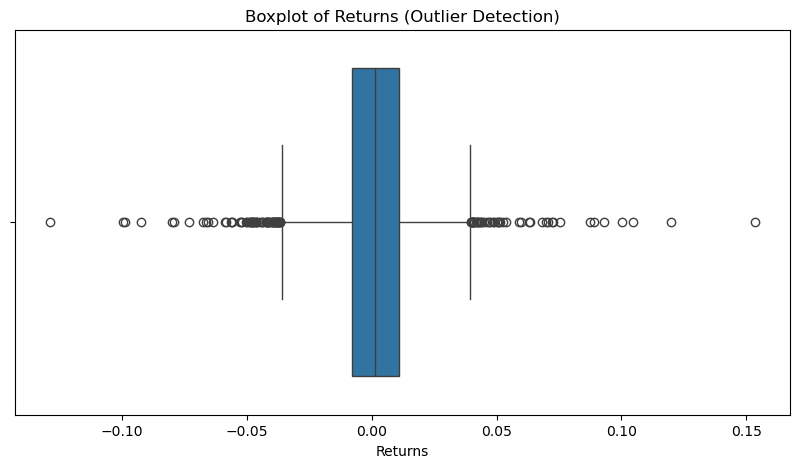

In [24]:
df_clean = df_clean.reset_index()

plt.figure(figsize=(10,5))
sns.boxplot(x=df_clean['Returns'])

plt.title("Boxplot of Returns (Outlier Detection)")
plt.xlabel("Returns")
plt.show()

## Diagnosis

Outliers can be identified using:

* Z-score method: values where |Z| > 3
* Boxplots: points outside whiskers
* Visual inspection of time series plot

### interpretation
A total of 29 outliers were detected, indicating the presence of extreme return values in the dataset.

###  Damage

Outliers can have several negative effects:

* Distort the mean and variance
* Bias regression estimates
* Lead to incorrect conclusions
* Increase volatility estimates in financial models

## Directions (HOW TO FIX)

To address outliers, the following approaches can be used:

 #### 1 Remove outliers
 #### 2 Winsorization (limit extreme values)
 #### 3 Use robust models
#### 4 Transform the data


 





---

### Citations

1. Gujarati, D. N., & Porter, D. C. (2009). *Basic econometrics* (5th ed.). McGraw-Hill Education.  
   [https://www.mheducation.com/highered/product/basic-econometrics-gujarati-porter/M9780073375779.html](https://www.mheducation.com/highered/product/basic-econometrics-gujarati-porter/M9780073375779.html)

2. Brooks, C. (2019). *Introductory econometrics for finance* (3rd ed.). Cambridge University Press.  
   [https://www.cambridge.org/highereducation/books/introductory-econometrics-for-finance/8C6C4D6C8E5B3E4A0A58E6A3A8F7E5C4](https://www.cambridge.org/highereducation/books/introductory-econometrics-for-finance/8C6C4D6C8E5B3E4A0A58E6A3A8F7E5C4)

3. Wooldridge, J. M. (2020). *Introductory econometrics: A modern approach* (7th ed.). Cengage Learning.  
   [https://www.cengage.com/c/introductory-econometrics-a-modern-approach-7e-wooldridge](https://www.cengage.com/c/introductory-econometrics-a-modern-approach-7e-wooldridge)

4. Tsay, R. S. (2010). *Analysis of financial time series* (3rd ed.). Wiley.  
   [https://www.wiley.com/en-us/Analysis+of+Financial+Time+Series%2C+3rd+Edition-p-9780470414354](https://www.wiley.com/en-us/Analysis+of+Financial+Time+Series%2C+3rd+Edition-p-9780470414354)

5. Montgomery, D. C., Peck, E. A., & Vining, G. G. (2021). *Introduction to linear regression analysis* (6th ed.). Wiley.  
   [https://www.wiley.com/en-us/Introduction+to+Linear+Regression+Analysis%2C+6th+Edition-p-9781119578727](https://www.wiley.com/en-us/Introduction+to+Linear+Regression+Analysis%2C+6th+Edition-p-9781119578727)

6. Hair, J. F., Black, W. C., Babin, B. J., & Anderson, R. E. (2019). *Multivariate data analysis* (8th ed.). Cengage Learning.  
   [https://www.cengage.com/c/multivariate-data-analysis-8e-hair](https://www.cengage.com/c/multivariate-data-analysis-8e-hair)

7. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An introduction to statistical learning: With applications in R* (2nd ed.). Springer.  
   [https://www.statlearning.com](https://www.statlearning.com)

8. Enders, W. (2014). *Applied econometric time series* (4th ed.). Wiley.  
   [https://www.wiley.com/en-us/Applied+Econometric+Time+Series%2C+4th+Edition-p-9781118808566](https://www.wiley.com/en-us/Applied+Econometric+Time+Series%2C+4th+Edition-p-9781118808566)

9. Greene, W. H. (2018). *Econometric analysis* (8th ed.). Pearson.  
   [https://www.pearson.com/en-us/subject-catalog/p/econometric-analysis/P200000003480](https://www.pearson.com/en-us/subject-catalog/p/econometric-analysis/P200000003480)

10. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.). Springer.  
    [https://hastie.su.domains/ElemStatLearn](https://hastie.su.domains/ElemStatLearn)

